In [1]:
# Load environment variables and set up auto-reload
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

# Multi-Agent Research System

This notebook combines all the previous components into a single system.

Here is our overall research flow:

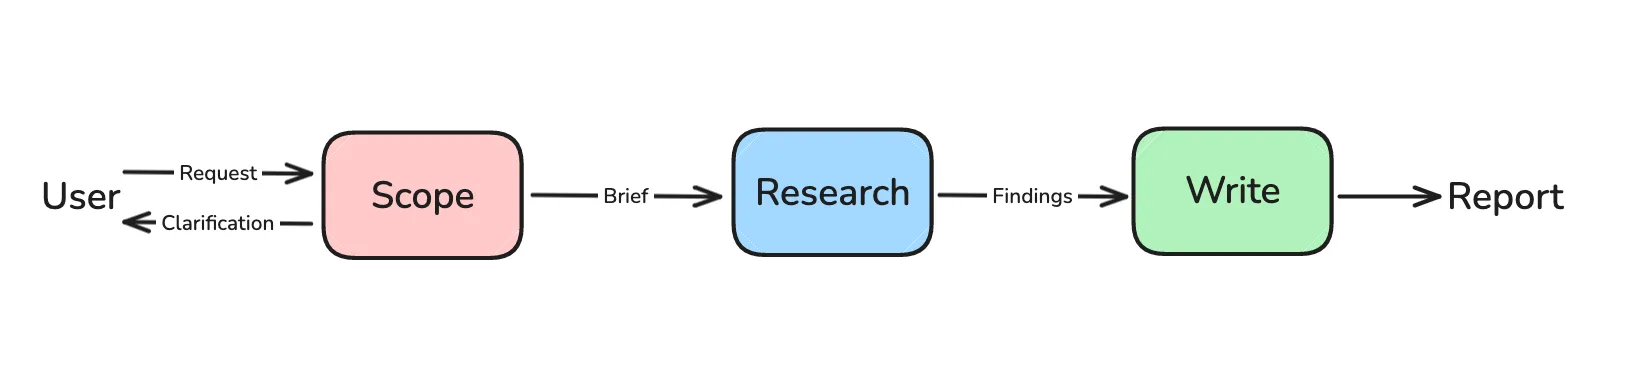

We've built research scoping and multi-agent research in previous notebooks.

Now, we'll add the final report generation step.

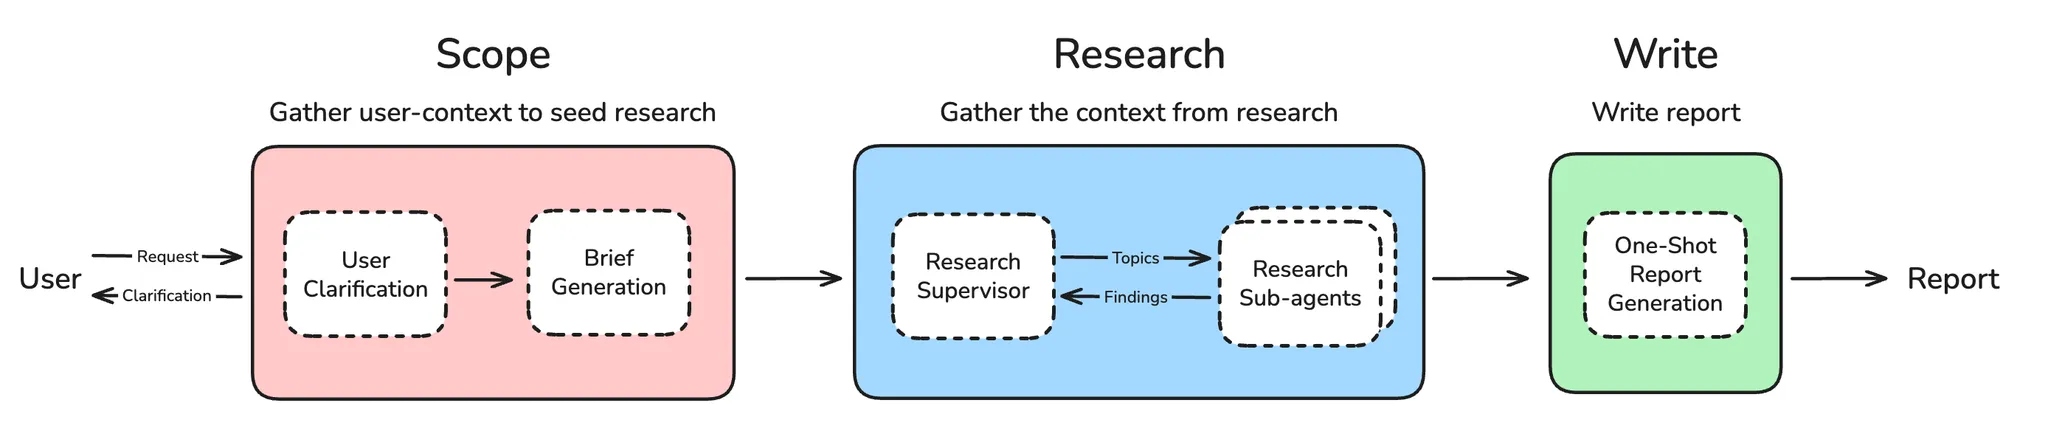

### Agent 

We simply can re-use the components we've already built.

In [2]:
%%writefile ../src/deep_research_from_scratch/research_agent_full.py

"""
Full Multi-Agent Research System

This module integrates all components of the research system:
- User clarification and scoping
- Research brief generation  
- Multi-agent research coordination
- Final report generation

The system orchestrates the complete research workflow from initial user
input through final report delivery.
"""

from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END

from deep_research_from_scratch.utils import get_today_str
from deep_research_from_scratch.prompts import final_report_generation_prompt
from deep_research_from_scratch.state_scope import AgentState, AgentInputState
from deep_research_from_scratch.research_agent_scope import clarify_with_user, write_research_brief
from deep_research_from_scratch.multi_agent_supervisor import supervisor_agent

# ===== Config =====

from langchain.chat_models import init_chat_model
writer_model = init_chat_model(model="openai:gpt-4.1", max_tokens=32000)

# ===== FINAL REPORT GENERATION =====

from deep_research_from_scratch.state_scope import AgentState

async def final_report_generation(state: AgentState):
    """
    Final report generation node.
    
    Synthesizes all research findings into a comprehensive final report
    """
    
    notes = state.get("notes", [])
    
    findings = "\n".join(notes)

    final_report_prompt = final_report_generation_prompt.format(
        research_brief=state.get("research_brief", ""),
        findings=findings,
        date=get_today_str()
    )
    
    final_report = await writer_model.ainvoke([HumanMessage(content=final_report_prompt)])
    
    return {
        "final_report": final_report.content, 
        "messages": ["Here is the final report: " + final_report.content],
    }

# ===== GRAPH CONSTRUCTION =====
# Build the overall workflow
deep_researcher_builder = StateGraph(AgentState, input_schema=AgentInputState)

# Add workflow nodes
deep_researcher_builder.add_node("clarify_with_user", clarify_with_user)
deep_researcher_builder.add_node("write_research_brief", write_research_brief)
deep_researcher_builder.add_node("supervisor_subgraph", supervisor_agent)
deep_researcher_builder.add_node("final_report_generation", final_report_generation)

# Add workflow edges
deep_researcher_builder.add_edge(START, "clarify_with_user")
deep_researcher_builder.add_edge("write_research_brief", "supervisor_subgraph")
deep_researcher_builder.add_edge("supervisor_subgraph", "final_report_generation")
deep_researcher_builder.add_edge("final_report_generation", END)

# Compile the full workflow
agent = deep_researcher_builder.compile()

Overwriting ../src/deep_research_from_scratch/research_agent_full.py


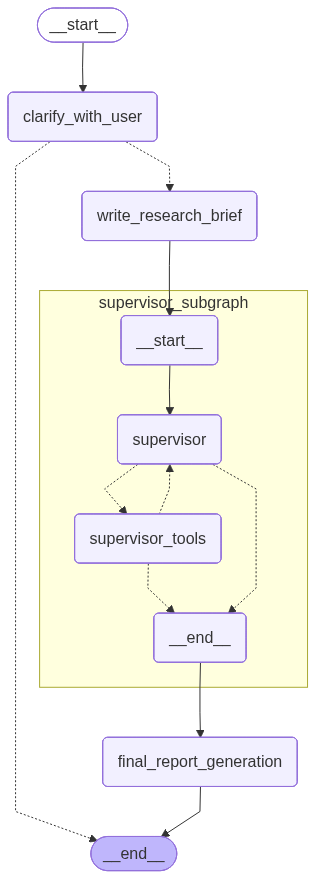

In [3]:
# Run the workflow
from utils import format_messages
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver
from deep_research_from_scratch.research_agent_full import deep_researcher_builder

checkpointer = InMemorySaver()
full_agent = deep_researcher_builder.compile(checkpointer=checkpointer)
display(Image(full_agent.get_graph(xray=True).draw_mermaid_png()))

LangGraph has a default recursion limit of 25 steps to prevent infinite loops. For complex research workflows that require iterative rounds of research, this limit needs to be increased. As explained in [LangGraph's troubleshooting guide](https://langchain-ai.github.io/langgraph/troubleshooting/errors/GRAPH_RECURSION_LIMIT/), the recursion limit counts every node execution in the graph. In our multi-agent research system:

- **Single Research Agent**: May take 8-12 steps for tool calls and compression
- **Multi-Agent Supervisor**: Each sub-agent spawned adds additional steps
- **Iterative Research**: Supervisor may conduct multiple rounds of research to fill gaps
- **Full Workflow**: Includes scoping, research brief generation, supervision, and report generation

We set the recursion limit to **50** to accommodate:
- Complex research topics requiring multiple research rounds
- Parallel sub-agent execution
- Deep research with many tool calls
- Complete workflow execution from scoping to final report

This allows the supervisor to conduct iterative rounds of research when initial findings have gaps, ensuring comprehensive coverage of complex research topics.

In [4]:
from langchain_core.messages import HumanMessage
thread = {"configurable": {"thread_id": "1", "recursion_limit": 50}}
result = await full_agent.ainvoke({"messages": [HumanMessage(content="Compare Gemini to OpenAI Deep Research agents.")]}, config=thread)
format_messages(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Compare Gemini to OpenAI Deep Research agents.                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Could you please clarify what you mean by "Gemini"? Are you referring to Google's Gemini AI model, or another   │
│ system? Also, by "OpenAI Deep Research agents," are you referring to a specific product or research tool from   │
│ OpenAI, such as GPT-4, OpenAI's autonomous agents, or something else? Please specify so I can provide an        │
│ accurate comparison.                                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [5]:
result = await full_agent.ainvoke({"messages": [HumanMessage(content="Yes the specific Deep Research products.")]}, config=thread)

Error in supervisor tools: 1 validation error for think_tool
reflection
  Field required [type=missing, input_value={}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.11/v/missing


In [6]:
format_messages(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Compare Gemini to OpenAI Deep Research agents.                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Could you please clarify what you mean by "Gemini"? Are you referring to Google's Gemini AI model, or another   │
│ system? Also, by "OpenAI Deep Research agents," are you referring to a specific product or research tool from   │
│ OpenAI, such as GPT-4, OpenAI's autonomous agents, or something else? Please specify so I can provide an        │
│ accurate comparison.                                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Yes the specific Deep Research products.                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Thank you for clarifying. I understand that you would like a comparison between Google's Gemini AI model and    │
│ OpenAI's specific Deep Research products. I will now begin the research and provide a detailed comparison based │
│ on the latest available information as of July 2026.                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Here is the final report: # Comprehensive Comparison: Google's Gemini AI Deep Research vs OpenAI Deep Research  │
│ Products (July 2026)                                                                                            │
│                                                                                                                 │
│ ## Introduction                                                                                                 │
│                                                                                                                 │
│ This report presents an in-depth comparison of Google's Gemini AI Deep Research models and OpenAI's suite of    │
│ Deep Research products as of July 2026. Both platforms represent the cutting edge in AI-driven research         │
│ assistants and autonomous research agents, serving business, academic, and individual research needs. The       │
│ analysis below covers model architectures, capabilities (including reasoning and autonomous agent features),    │
│ performance benchmarks, integration options, use cases, deployment, scalability, security, and other important  │
│ dimensions such as pricing, user interface, and support.                                                        │
│                                                                                                                 │
│ ## Overview: Google Gemini Deep Research                                                                        │
│                                                                                                                 │
│ ### Model Architecture                                                                                          │
│                                                                                                                 │
│ - **Core Models:** Gemini 2.5 Pro, 2.5 Flash, 3.1 Pro, 3.5 Flash, Deep Think, and Ultra, scaling up to an       │
│ estimated 1 trillion parameters.                                                                                │
│ - **Architecture:** Mixture-of-Experts (MoE) transformers with hierarchical memory, dual-encoder and            │
│ cross-modal decoder design, native multimodal support (text, image, audio, video, code), and the largest        │
│ available context window (up to 2 million tokens in enterprise settings) [1][2][3].                             │
│ - **Reasoning:** Advanced "thinking" capability using step-by-step, compute-intensive reasoning during          │
│ inference, often pausing to plan and critique before output [4][5].                                             │
│ - **Specialization:** Pedagogically-tuned variants (LearnLM), agentic models (Deep Research),                   │
│ retrieval-augmented generation (RAG), and support for memory persistence across sessions [6].                   │
│                                                                                                                 │
│ ### Capabilities                                                                                                │
│                                                                                                                 │
│ - **Autonomous Research:** Deep Research agent can autonomously plan, search, read, analyze, and synthesize     │
│ multi-step research reports, leveraging Google Search, user documents (Gmail, Drive, Chat), real-time web       │
│ browsing, and multimodal file inputs (PDFs, images, audio, video) [7][8][9].                                    │
│ - **Agentic Features:** Models excel at hierarchical task decomposition, asynchronous task execution, parallel  │
│ multimodal reasoning, and iterative self-critique—mirroring how a multi-stage human research team might work    │
│ [7].                                                   

In [7]:
from rich.markdown import Markdown
Markdown(result["final_report"])

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Comprehensive Comparison: Google's Gemini AI Deep Research vs OpenAI Deep Research Products (July 2026)     ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛


                                                   Introduction                                                    

This report presents an in-depth comparison of Google's Gemini AI Deep Research models and OpenAI's suite of Deep  
Research products as of July 2026. Both platforms represent the cutting edge in AI-driven research assistants and  
autonomous research agents, serving business, academic, and individual research needs. The analysis below covers   
model architectures, capabilities (including reasoning and autonomous agent features), performance benchmarks,     
integration options, use cases, deployment, scalability, security, and other important dimensions such as pricing, 
user interface, and support.                                                                                       


                                       Overview: Google Gemini Deep Research                                       

                                                Model Architecture                                                 

 • Core Models: Gemini 2.5 Pro, 2.5 Flash, 3.1 Pro, 3.5 Flash, Deep Think, and Ultra, scaling up to an estimated 1 
   trillion parameters.                                                                                            
 • Architecture: Mixture-of-Experts (MoE) transformers with hierarchical memory, dual-encoder and cross-modal      
   decoder design, native multimodal support (text, image, audio, video, code), and the largest available context  
   window (up to 2 million tokens in enterprise settings) [1][2][3].                                               
 • Reasoning: Advanced "thinking" capability using step-by-step, compute-intensive reasoning during inference,     
   often pausing to plan and critique before output [4][5].                                                        
 • Specialization: Pedagogically-tuned variants (LearnLM), agentic models (Deep Research), retrieval-augmented     
   generation (RAG), and support for memory persistence across sessions [6].                                       

                                                   Capabilities                                                    

 • Autonomous Research: Deep Research agent can autonomously plan, search, read, analyze, and synthesize multi-step
   research reports, leveraging Google Search, user documents (Gmail, Drive, Chat), real-time web browsing, and    
   multimodal file inputs (PDFs, images, audio, video) [7][8][9].                                                  
 • Agentic Features: Models excel at hierarchical task decomposition, asynchronous task execution, parallel        
   multimodal reasoning, and iterative self-critique—mirroring how a multi-stage human research team might work    
   [7].                                                                                                            
 • Multimodal: Natively interprets and reasons over text, images, video, audio, spreadsheets, and code—including   
   advanced features like YouTube/video analysis and context-aware podcast generation [2][10].                     
 • Integration: Tightly embedded into Google Workspace (Docs, Sheets, Slides, Gmail, Drive, Chat), Google Cloud    
   Vertex AI, and customizable through API, SDK, and LangGraph orchestration [11][12][13].                         
 • Interactive Content: Generates structured multi-page reports, audio/podcast summaries, rich visuals, and        
   exportable in various formats. Supports human-in-the-loop with reviewable and revisable research plans [7][10]. 
 • Scalability: Supports asynchronous, long-run

We can see the trace [here](https://smith.langchain.com/public/86ebdc25-4595-4040-be1e-a8e30052786b/r).

### LangGraph Studio

Just as we did before, we can also use LangGraph Studio to visualize the agent. 

The files we wrote with `%%writefile` to `src/deep_research_from_scratch/` during the all the notebooks create the files for our application:

```
deep_research_from_scratch/
├── src/deep_research_from_scratch/
│   ├── state.py          # State definitions
│   ├── scope_research.py # Scoping workflow
│   ├── prompts.py        # Prompt templates
│   └── ...
├── notebooks/            # Development notebooks
├── pyproject.toml        # Dependencies
└── langgraph.json        # LangGraph configuration
```

This agent has been added to the `langgraph.json` file, so you can select `research_agent_full` in the dropdown menu:

```
"research_agent_full": "./src/deep_research_from_scratch/research_agent_full.py:agent"
```

Run the following command to start the studio

```bash
uvx --refresh --from "langgraph-cli[inmem]" --with-editable . --python 3.11 langgraph dev --allow-blocking
```

## curl request

In [8]:
import requests

BASE_URL = "http://127.0.0.1:2024"

schema = requests.get(f"{BASE_URL}/openapi.json").json()
paths = schema["paths"].keys()

[p for p in paths if "assistants" in p]

['/assistants',
 '/assistants/search',
 '/assistants/count',
 '/assistants/{assistant_id}',
 '/assistants/{assistant_id}/graph',
 '/assistants/{assistant_id}/subgraphs',
 '/assistants/{assistant_id}/subgraphs/{namespace}',
 '/assistants/{assistant_id}/schemas',
 '/assistants/{assistant_id}/versions',
 '/assistants/{assistant_id}/latest']

In [2]:
import requests

BASE_URL = "http://127.0.0.1:2024"

search_payload = {
    "offset": 0,
    "limit": 20,
    "metadata": {}  # must be an object, not null
    # you can also just drop "metadata" entirely
}

resp = requests.post(f"{BASE_URL}/assistants/search", json=search_payload)
print("Status:", resp.status_code)
print("Body:", resp.text)

assistants = resp.json()
for a in assistants:
    print(a)

Status: 200
Body: [{"assistant_id":"6fc3e7f8-200f-5621-9e19-0634de120ef4","graph_id":"docs_assistant","config":{},"context":{},"metadata":{"created_by":"system"},"name":"docs_assistant","created_at":"2026-05-01T14:59:29.574067+00:00","updated_at":"2026-05-01T14:59:29.574067+00:00","version":1,"description":null},{"assistant_id":"48edc2f9-e95a-51f0-ad9d-624769bfe4dd","graph_id":"research_agent_supervisor","config":{},"context":{},"metadata":{"created_by":"system"},"name":"research_agent_supervisor","created_at":"2026-05-01T14:59:28.660220+00:00","updated_at":"2026-05-01T14:59:28.660220+00:00","version":1,"description":null},{"assistant_id":"739269e3-c88e-5929-8e4f-54e657be315a","graph_id":"scope_research","config":{},"context":{},"metadata":{"created_by":"system"},"name":"scope_research","created_at":"2026-05-01T14:59:25.257115+00:00","updated_at":"2026-05-01T14:59:25.257115+00:00","version":1,"description":null},{"assistant_id":"10770da1-72cd-522a-b5d6-b69efc68eb94","graph_id":"researc

In [8]:
   import requests

   BASE_URL = "http://127.0.0.1:8000"

   payload = {
       "query": "Compare Claude, GPT-4.1, and Gemini for enterprise deep research workflows."
   }

   resp = requests.post(f"{BASE_URL}/deep_research", json=payload)
   resp.raise_for_status()

   data = resp.json()
   print("Keys:", data.keys())
   print("\nFinal report:\n")
   print(data["final_report"])

Keys: dict_keys(['final_report'])

Final report:

**List of Queries and Tool Calls Made:**
1. "Claude vs GPT-4.1 vs Gemini enterprise deep research workflows comparison 2024"
2. "Claude enterprise context window research document analysis multi-document workflows"
3. "GPT-4.1 enterprise API context window research document analysis capabilities 2024"
4. "Google Gemini 2.5 enterprise research capabilities multimodal document analysis API features"

---

**Fully Comprehensive Findings**

As of 2026, the enterprise AI landscape is dominated by four major platforms: OpenAI's ChatGPT Enterprise, Anthropic's Claude Enterprise, Microsoft's Copilot suite, and Google's Gemini Enterprise. Each platform offers unique strengths tailored to different business needs. ChatGPT Enterprise, built on GPT-5.2, is widely adopted across Fortune 500 companies, known for broad capabilities, extensive ecosystem, and enterprise-grade security with unlimited usage and long context windows. Claude Enterprise spec

In [9]:
import requests

BASE_URL = "http://127.0.0.1:8000"

payload = {
    "query": "Summarize the local coffee_shops_sf.md file and explain what makes a great specialty coffee shop."
}

resp = requests.post(f"{BASE_URL}/deep_research_mcp", json=payload)
resp.raise_for_status()

data = resp.json()
print("Final report (MCP):\n")
print(data["final_report"])

Final report (MCP):

**List of Queries and Tool Calls Made**
1. Located the file coffee_shops_sf.md in the directory C:\Users\skand\Dropbox\github\deep_research_from_scratch\src\deep_research_from_scratch\files.
2. Read the entire contents of coffee_shops_sf.md to capture details about coffee shops in San Francisco.

**Fully Comprehensive Findings**

# San Francisco Coffee Shops Research

## Top Coffee Shops in San Francisco

### Blue Bottle Coffee
- **Founded**: 2002 in Oakland, expanded to SF
- **Specialty**: Single-origin coffee, pour-over methods
- **Notable**: Known for freshly roasted beans, minimalist aesthetic
- **Locations**: Multiple SF locations including Ferry Building

### Philz Coffee
- **Founded**: 2003 in San Francisco
- **Specialty**: Custom blended coffee, personalized service
- **Notable**: Founded by Phil Jaber, known for unique blends like "Tesora"
- **Locations**: Original location in Mission District, now citywide

### Sightglass Coffee
- **Founded**: 2009
- **Sp

In [ ]:
1